<a href="https://colab.research.google.com/github/PalakAggarwal13/OpenCV/blob/main/Project-Face_Recognition/Face_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import os
import cv2
import numpy as np
import urllib.request
from google.colab.patches import cv2_imshow

In [58]:
!git clone https://github.com/jasmcaus/opencv-course.git

fatal: destination path 'opencv-course' already exists and is not an empty directory.


In [59]:
import os

DIR = "/content/opencv-course/Resources/Faces/train"

if os.path.exists(DIR):
    print("✅ Path exists!")
else:
    print("❌ Path does NOT exist!")

✅ Path exists!


In [60]:
files = os.listdir("/content/opencv-course/Resources/Faces/train")
print(files)

['Elton John', 'Jerry Seinfield', 'Mindy Kaling', 'Madonna', 'Ben Afflek']


In [61]:
people = ['Elton John', 'Jerry Seinfield', 'Mindy Kaling', 'Madonna', 'Ben Afflek']

In [62]:
from google.colab import files
uploaded = files.upload()

Saving haar_face_data.xml to haar_face_data (1).xml


In [63]:
haar_cascade = cv2.CascadeClassifier('haar_face_data.xml')

In [64]:
!pip install opencv-contrib-python --upgrade

In [72]:
features = []
labels = []

def create_train():
  for person in people:
    path = os.path.join(DIR,person)
    label = people.index(person)

    for img in os.listdir(path):
      img_path = os.path.join(path,img)

      img_array = cv2.imread(img_path)
      gray = cv2.cvtColor(img_array , cv2.COLOR_BGR2GRAY)

      faces_rect = haar_cascade.detectMultiScale(gray , scaleFactor=1.1 , minNeighbors = 4)
      for (x,y,w,h) in faces_rect:
        faces_roi = gray[y:y+h,x:x+w]
        faces_roi_resized = cv2.resize(faces_roi, (200, 200))
        features.append(faces_roi)
        labels.append(label)

In [73]:
print(f'length of features: {len(features)}')
print(f'length of labels: {len(labels)}')

length of features: 0
length of labels: 0


In [74]:
create_train()
print('Training done --------------')
features = np.array(features,dtype='object')
labels = np.array(labels)

Training done --------------


In [75]:
face_recognizer = cv2.face.LBPHFaceRecognizer_create()
face_recognizer.train(features,labels)
face_recognizer.save('face_trained.yml')
np.save('features.npy',features)
np.save('labels.npy',labels)

# **BUILDING A MODEL**

Label = Jerry Seinfield with a confidence of 0.0


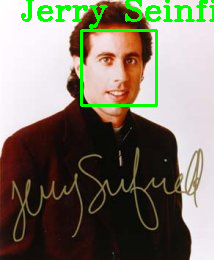

In [90]:
import numpy as np
import cv2

haar_cascade = cv2.CascadeClassifier('haar_face_data.xml')

people = ['Elton John', 'Jerry Seinfield', 'Mindy Kaling', 'Madonna', 'Ben Afflek']
features = np.load('features.npy',allow_pickle=True)
labels = np.load('labels.npy',allow_pickle=True)

face_recognizer = cv2.face.LBPHFaceRecognizer_create()
face_recognizer.read('face_trained.yml')

url1 = "https://raw.githubusercontent.com/jasmcaus/opencv-course/c028d3624fd77f34ae9f1a57a13106551a018c4c/Resources/Faces/train/Ben%20Afflek/13.jpg"

url = "https://raw.githubusercontent.com/jasmcaus/opencv-course/c028d3624fd77f34ae9f1a57a13106551a018c4c/Resources/Faces/train/Jerry%20Seinfield/17.jpg"
# Download image from URL
resp = urllib.request.urlopen(url)
img_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)

# Decode into OpenCV format
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

faces_rect = haar_cascade.detectMultiScale(gray ,1.1 , 4)
for (x,y,w,h) in faces_rect:
  faces_roi = gray[y:y+h,x:x+w]

  label , confidence = face_recognizer.predict(faces_roi)
  print(f'Label = {people[label]} with a confidence of {confidence}')

  cv2.putText(img , str(people[label]) , (20,20) , cv2.FONT_HERSHEY_COMPLEX , 1.0,(0,255,0) , thickness=2)
  cv2.rectangle(img,(x,y) , (x+w,y+h) , (0,255,0) , thickness=2)

cv2_imshow(img)


In [88]:
test_face_resized = cv2.resize(test_face, (200, 200))
label, confidence = face_recognizer.predict(test_face_resized)
print(label, confidence)

0 53.6020871865056
